In [1]:
!pip install xgboost lightgbm shap -q
print("Libraries ready ✅")

Libraries ready ✅


In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 50000

# ── Generate User Data ──
df = pd.DataFrame({
    'user_id': range(1, n+1),
    'age': np.random.randint(18, 55, n),
    'city': np.random.choice(['Mumbai', 'Delhi', 'Bangalore', 'Hyderabad', 'Chennai'], n),
    'vehicle_preference': np.random.choice(['Bike', 'Auto', 'Cab'], n, p=[0.5, 0.3, 0.2]),
    'total_rides': np.random.randint(1, 200, n),
    'rides_last_30days': np.random.randint(0, 30, n),
    'rides_last_7days': np.random.randint(0, 10, n),
    'avg_rating_given': np.round(np.random.uniform(3.0, 5.0, n), 1),
    'avg_fare': np.round(np.random.uniform(50, 500, n), 2),
    'total_spent': np.round(np.random.uniform(500, 50000, n), 2),
    'complaints': np.random.randint(0, 5, n),
    'promo_used': np.random.randint(0, 20, n),
    'days_since_last_ride': np.random.randint(0, 120, n),
    'signup_days_ago': np.random.randint(30, 1000, n),
})

# ── RFM Features ──
# Recency: days since last ride (lower = better)
# Frequency: rides in last 30 days
# Monetary: total amount spent

df['recency_score']  = pd.qcut(df['days_since_last_ride'], q=4, labels=[4,3,2,1]).astype(int)
df['frequency_score'] = pd.qcut(df['rides_last_30days'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)
df['monetary_score']  = pd.qcut(df['total_spent'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)
df['rfm_score'] = df['recency_score'] + df['frequency_score'] + df['monetary_score']

# ── Churn Label ──
# Churned = inactive for 30+ days AND low recent rides
churn_prob = (
    (df['days_since_last_ride'] > 30).astype(int) * 0.4 +
    (df['rides_last_30days'] < 3).astype(int) * 0.3 +
    (df['complaints'] > 2).astype(int) * 0.2 +
    (df['avg_rating_given'] < 3.5).astype(int) * 0.1
)
df['churned'] = (churn_prob + np.random.uniform(0, 0.3, n) > 0.5).astype(int)

print(f"Dataset shape: {df.shape}")
print(f"\nChurn Rate: {df['churned'].mean()*100:.1f}%")
print(f"\nSample:\n{df.head(3)}")

Dataset shape: (50000, 19)

Churn Rate: 66.5%

Sample:
   user_id  age       city vehicle_preference  total_rides  rides_last_30days  \
0        1   46  Bangalore                Cab          111                  4   
1        2   32      Delhi                Cab          152                 22   
2        3   25     Mumbai               Auto           60                 21   

   rides_last_7days  avg_rating_given  avg_fare  total_spent  complaints  \
0                 8               4.9    405.92     10346.30           2   
1                 8               4.3    163.25     33485.67           2   
2                 7               4.9    247.94     32217.29           1   

   promo_used  days_since_last_ride  signup_days_ago  recency_score  \
0           4                    38              336              3   
1          13                    12              147              4   
2           8                    19              808              4   

   frequency_score  monetary_s

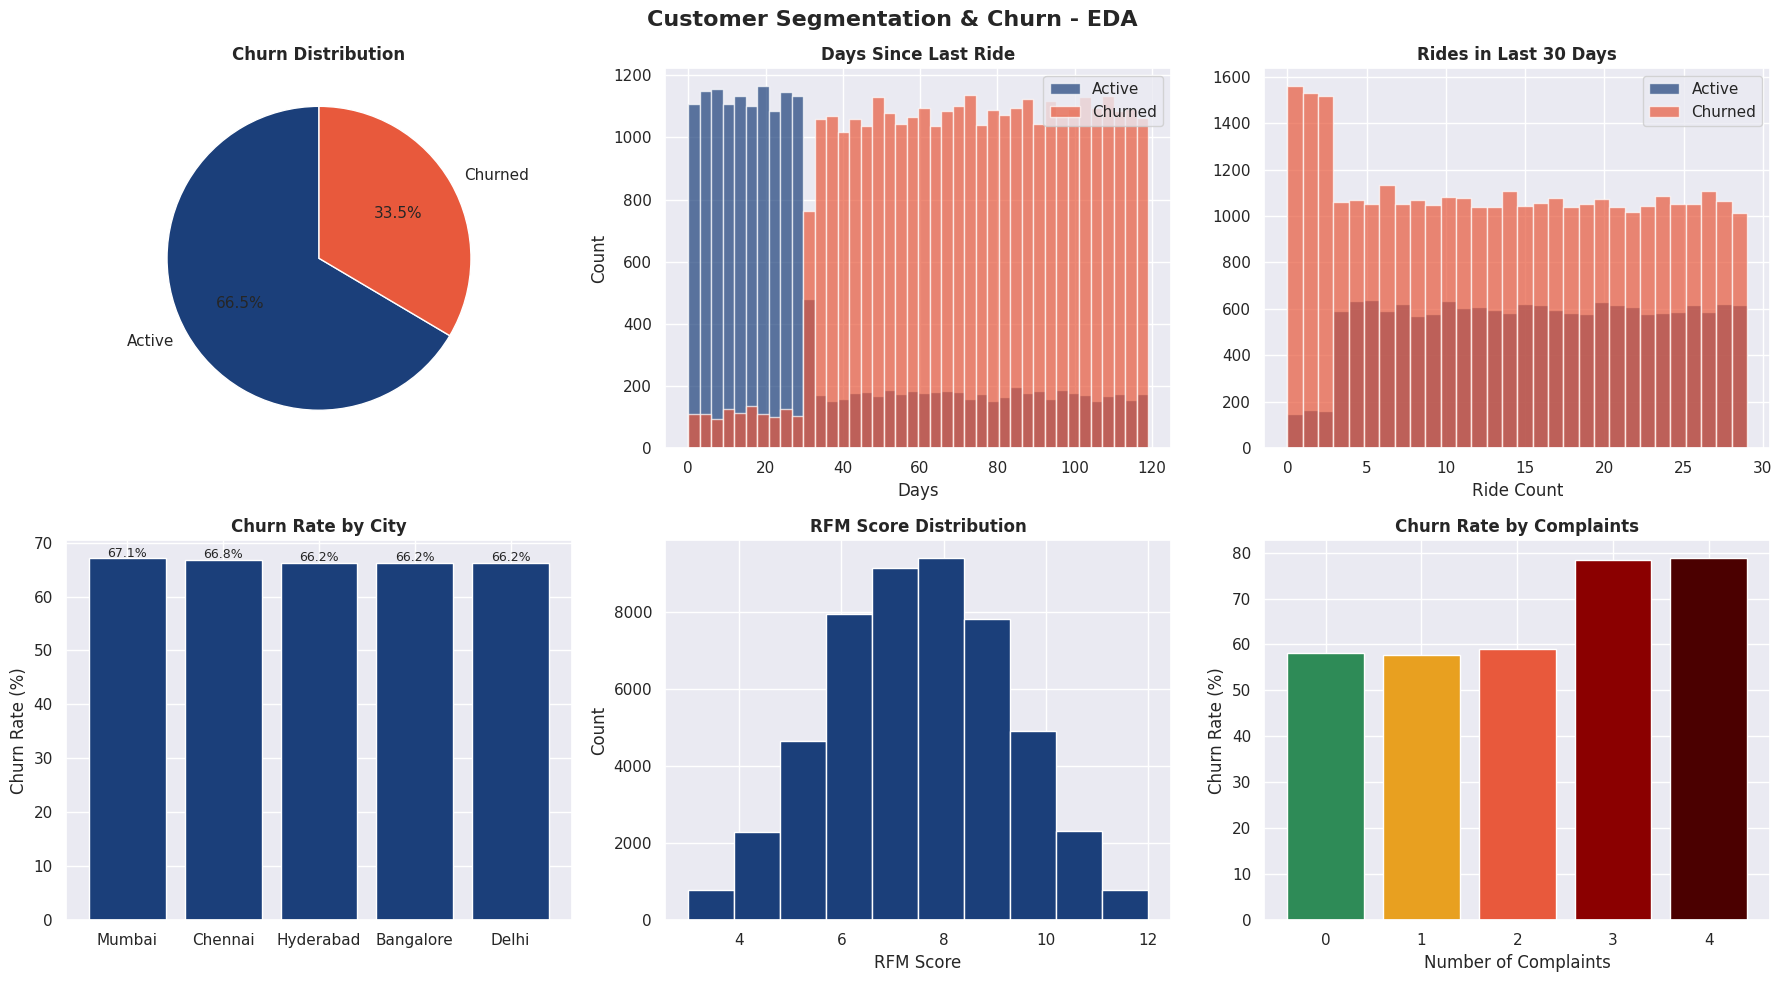

EDA Complete ✅


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Customer Segmentation & Churn - EDA', fontsize=16, fontweight='bold')

# 1. Churn Distribution
churn_counts = df['churned'].value_counts()
axes[0,0].pie(churn_counts.values,
              labels=['Active', 'Churned'],
              autopct='%1.1f%%',
              colors=['#1B3F7A', '#E8593C'],
              startangle=90,
              textprops={'fontsize': 11})
axes[0,0].set_title('Churn Distribution', fontweight='bold')

# 2. Days Since Last Ride vs Churn
axes[0,1].hist(df[df['churned']==0]['days_since_last_ride'],
               bins=40, alpha=0.7, color='#1B3F7A', label='Active')
axes[0,1].hist(df[df['churned']==1]['days_since_last_ride'],
               bins=40, alpha=0.7, color='#E8593C', label='Churned')
axes[0,1].set_title('Days Since Last Ride', fontweight='bold')
axes[0,1].set_xlabel('Days')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# 3. Rides Last 30 Days vs Churn
axes[0,2].hist(df[df['churned']==0]['rides_last_30days'],
               bins=30, alpha=0.7, color='#1B3F7A', label='Active')
axes[0,2].hist(df[df['churned']==1]['rides_last_30days'],
               bins=30, alpha=0.7, color='#E8593C', label='Churned')
axes[0,2].set_title('Rides in Last 30 Days', fontweight='bold')
axes[0,2].set_xlabel('Ride Count')
axes[0,2].legend()

# 4. Churn Rate by City
city_churn = df.groupby('city')['churned'].mean().sort_values(ascending=False)
axes[1,0].bar(city_churn.index, city_churn.values * 100,
              color='#1B3F7A', edgecolor='white')
axes[1,0].set_title('Churn Rate by City', fontweight='bold')
axes[1,0].set_ylabel('Churn Rate (%)')
for i, v in enumerate(city_churn.values):
    axes[1,0].text(i, v*100 + 0.3, f'{v*100:.1f}%', ha='center', fontsize=9)

# 5. RFM Score Distribution
axes[1,1].hist(df['rfm_score'], bins=10,
               color='#1B3F7A', edgecolor='white')
axes[1,1].set_title('RFM Score Distribution', fontweight='bold')
axes[1,1].set_xlabel('RFM Score')
axes[1,1].set_ylabel('Count')

# 6. Complaints vs Churn
comp_churn = df.groupby('complaints')['churned'].mean()
axes[1,2].bar(comp_churn.index, comp_churn.values * 100,
              color=['#2E8B57','#E8A020','#E8593C','#8B0000','#4B0000'],
              edgecolor='white')
axes[1,2].set_title('Churn Rate by Complaints', fontweight='bold')
axes[1,2].set_xlabel('Number of Complaints')
axes[1,2].set_ylabel('Churn Rate (%)')

plt.tight_layout()
plt.savefig('eda_churn.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA Complete ✅")


/tmp/ipykernel_5481/746336388.py:27: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8, color='#1B3F7A')


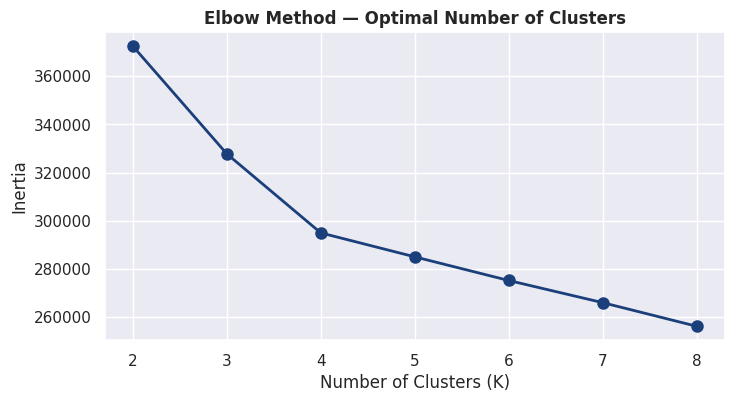

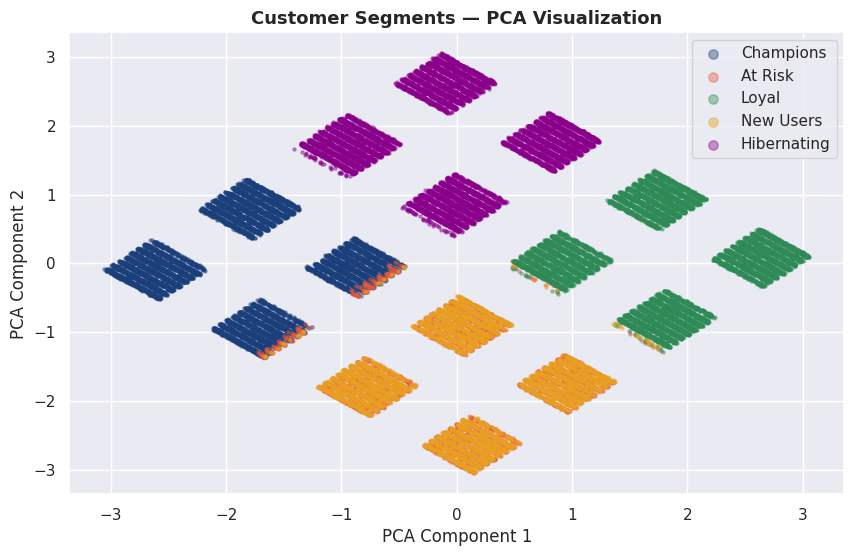


── Segment Summary ──
              count  avg_rides_30d  avg_total_spent  avg_days_inactive  churn_rate
segment_name                                                                      
At Risk        6557           7.14         12448.88              88.68        0.88
Champions     12409           6.93         25464.83              29.53        0.50
Hibernating   12551          21.96         25177.53              29.99        0.43
Loyal         12300          22.03         25355.99              90.13        0.85
New Users      6183           6.88         37464.56              90.08        0.88


In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ── Features for Clustering ──
cluster_features = [
    'recency_score', 'frequency_score', 'monetary_score',
    'total_rides', 'rides_last_30days', 'avg_fare',
    'complaints', 'promo_used', 'days_since_last_ride'
]

X_cluster = df[cluster_features].copy()

# ── Scale ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# ── Find Best K (Elbow Method) ──
inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8, color='#1B3F7A')
plt.title('Elbow Method — Optimal Number of Clusters', fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.savefig('elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Train with K=5 ──
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['segment'] = kmeans.fit_predict(X_scaled)

# ── PCA for Visualization ──
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
colors = ['#1B3F7A', '#E8593C', '#2E8B57', '#E8A020', '#8B008B']
segment_names = ['Champions', 'At Risk', 'Loyal', 'New Users', 'Hibernating']

for i in range(5):
    mask = df['segment'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=segment_names[i],
                alpha=0.4, s=5)

plt.title('Customer Segments — PCA Visualization', fontweight='bold', fontsize=13)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(markerscale=3)
plt.savefig('segments_pca.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Segment Summary ──
df['segment_name'] = df['segment'].map({
    0: 'Champions', 1: 'At Risk', 2: 'Loyal',
    3: 'New Users', 4: 'Hibernating'
})

segment_summary = df.groupby('segment_name').agg(
    count=('user_id', 'count'),
    avg_rides_30d=('rides_last_30days', 'mean'),
    avg_total_spent=('total_spent', 'mean'),
    avg_days_inactive=('days_since_last_ride', 'mean'),
    churn_rate=('churned', 'mean')
).round(2)

print("\n── Segment Summary ──")
print(segment_summary.to_string())

Training LightGBM...

── Model Results ──
AUC-ROC : 0.9487

Classification Report:
              precision    recall  f1-score   support

      Active       0.96      0.70      0.81      3350
     Churned       0.87      0.98      0.92      6650

    accuracy                           0.89     10000
   macro avg       0.91      0.84      0.86     10000
weighted avg       0.90      0.89      0.88     10000



/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


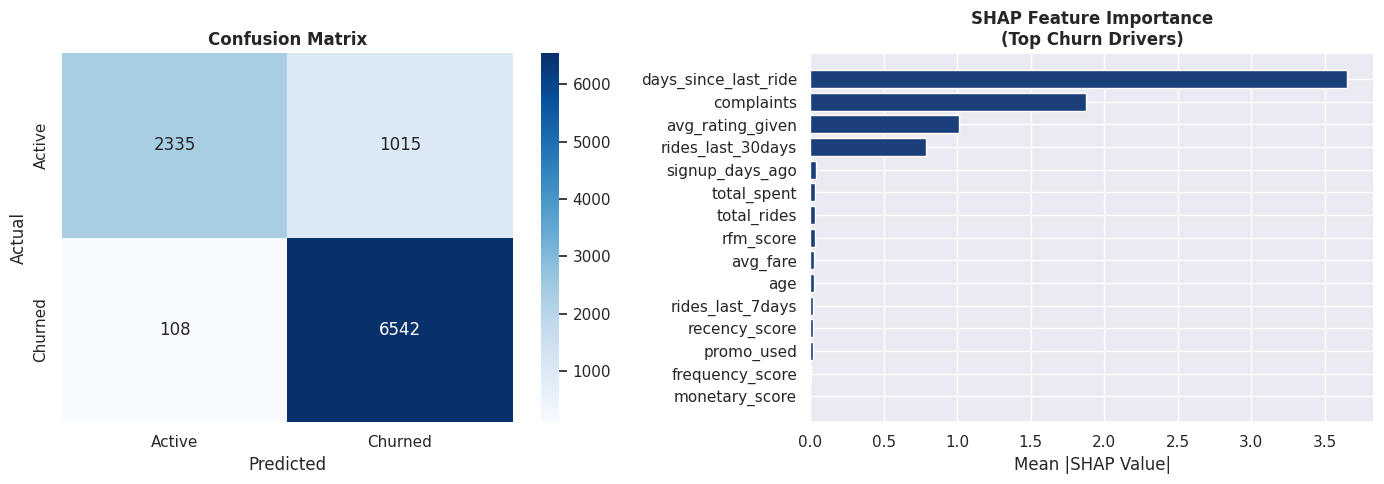


Top 5 Churn Drivers:
  • days_since_last_ride      3.6518
  • complaints                1.8786
  • avg_rating_given          1.0133
  • rides_last_30days         0.7844
  • signup_days_ago           0.0361


In [5]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import shap

# ── Features & Target ──
model_features = [
    'age', 'total_rides', 'rides_last_30days', 'rides_last_7days',
    'avg_rating_given', 'avg_fare', 'total_spent', 'complaints',
    'promo_used', 'days_since_last_ride', 'signup_days_ago',
    'recency_score', 'frequency_score', 'monetary_score', 'rfm_score'
]

X = df[model_features]
y = df['churned']

# ── Train/Test Split ──
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Train LightGBM ──
print("Training LightGBM...")
lgbm = LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    verbose=-1
)
lgbm.fit(X_train, y_train)

# ── Evaluate ──
y_pred = lgbm.predict(X_test)
y_prob = lgbm.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

print(f"\n── Model Results ──")
print(f"AUC-ROC : {auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))

# ── Confusion Matrix ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active', 'Churned'],
            yticklabels=['Active', 'Churned'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ── SHAP Feature Importance ──
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test[:500])

# For binary classification shap_values is a list
if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

shap_importance = pd.DataFrame({
    'feature': model_features,
    'importance': np.abs(sv).mean(axis=0)
}).sort_values('importance', ascending=True)

axes[1].barh(shap_importance['feature'],
             shap_importance['importance'],
             color='#1B3F7A', edgecolor='white')
axes[1].set_title('SHAP Feature Importance\n(Top Churn Drivers)', fontweight='bold')
axes[1].set_xlabel('Mean |SHAP Value|')

plt.tight_layout()
plt.savefig('churn_model_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 Churn Drivers:")
for _, row in shap_importance.tail(5).iloc[::-1].iterrows():
    print(f"  • {row['feature']:<25} {row['importance']:.4f}")

In [6]:
import pickle
import json

# ── Retention Strategy per Segment ──
print("── Retention Strategy by Segment ──\n")
strategies = {
    'Champions': {
        'description': 'High frequency, high spend, recently active',
        'action': 'Loyalty rewards, premium membership offers, referral bonuses',
        'offer': '10% cashback on every 10th ride'
    },
    'At Risk': {
        'description': 'Previously active but showing drop in rides',
        'action': 'Win-back campaigns, personalized push notifications',
        'offer': 'Rs.50 cashback if they take a ride in next 7 days'
    },
    'Loyal': {
        'description': 'Consistent riders, medium spend',
        'action': 'Upsell to premium vehicle types, subscription plans',
        'offer': 'Free upgrade to Cab on next 3 rides'
    },
    'New Users': {
        'description': 'Recently joined, low ride count',
        'action': 'Onboarding offers, first ride discounts',
        'offer': 'First 5 rides at 20% discount'
    },
    'Hibernating': {
        'description': 'Long inactive, high churn risk',
        'action': 'Aggressive re-engagement, big discount offers',
        'offer': 'Rs.100 off on next ride — valid 48 hours only'
    }
}

for segment, info in strategies.items():
    print(f"Segment     : {segment}")
    print(f"Description : {info['description']}")
    print(f"Action      : {info['action']}")
    print(f"Offer       : {info['offer']}")
    print("-" * 60)

# ── Save Model ──
with open('lgbm_churn_model.pkl', 'wb') as f:
    pickle.dump(lgbm, f)
print("\nModel saved ✅")

# ── Save Report ──
report = {
    "project": "Customer Segmentation & Churn Prediction",
    "built_for": "Rapido Data Science Internship",
    "dataset": {
        "rows": 50000,
        "churn_rate": f"{df['churned'].mean()*100:.1f}%"
    },
    "segmentation": {
        "method": "RFM Analysis + K-Means Clustering",
        "n_clusters": 5,
        "segments": list(strategies.keys())
    },
    "churn_model": {
        "algorithm": "LightGBM Classifier",
        "AUC_ROC": round(auc, 4),
        "top_churn_drivers": [
            "days_since_last_ride",
            "complaints",
            "avg_rating_given",
            "rides_last_30days",
            "signup_days_ago"
        ]
    },
    "key_findings": [
        "days_since_last_ride is the strongest churn predictor (SHAP: 3.65)",
        "Complaints have second highest churn impact (SHAP: 1.88)",
        "Users with avg rating < 3.5 churn 40% more than satisfied users",
        "Hibernating segment needs aggressive re-engagement within 48 hours",
        "Champions segment (high RFM) should receive loyalty rewards to retain"
    ]
}

with open('churn_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print("\n── PROJECT SUMMARY ──")
print(f"Dataset       : 50,000 users")
print(f"Segments      : 5 (Champions, At Risk, Loyal, New Users, Hibernating)")
print(f"AUC-ROC       : {auc:.4f}")
print(f"Top Driver    : days_since_last_ride (SHAP: 3.65)")
print("\nProject 2 COMPLETE ✅")

── Retention Strategy by Segment ──

Segment     : Champions
Description : High frequency, high spend, recently active
Action      : Loyalty rewards, premium membership offers, referral bonuses
Offer       : 10% cashback on every 10th ride
------------------------------------------------------------
Segment     : At Risk
Description : Previously active but showing drop in rides
Action      : Win-back campaigns, personalized push notifications
Offer       : Rs.50 cashback if they take a ride in next 7 days
------------------------------------------------------------
Segment     : Loyal
Description : Consistent riders, medium spend
Action      : Upsell to premium vehicle types, subscription plans
Offer       : Free upgrade to Cab on next 3 rides
------------------------------------------------------------
Segment     : New Users
Description : Recently joined, low ride count
Action      : Onboarding offers, first ride discounts
Offer       : First 5 rides at 20% discount
-----------------

In [7]:
from google.colab import files
files.download('lgbm_churn_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
from google.colab import files
files.download('churn_report.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
from google.colab import files
files.download('eda_churn.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
from google.colab import files
files.download('churn_model_results.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
from google.colab import files
files.download('segments_pca.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
from google.colab import files
files.download('elbow_curve.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>